# Aprendizado Não Supervisionado - DBSCAN

- **Importando o dataset iris**
    - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html

In [1]:
# Importando o dataset iris
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True, as_frame=True)

In [2]:
# Selecionando apenas as colunas de pétala
X = X.loc[:, ['petal length (cm)', 'petal width (cm)']]

- **Visualizando graficamente os pontos**
    - https://matplotlib.org/stable/plot_types/basic/scatter_plot.html#sphx-glr-plot-types-basic-scatter-plot-py

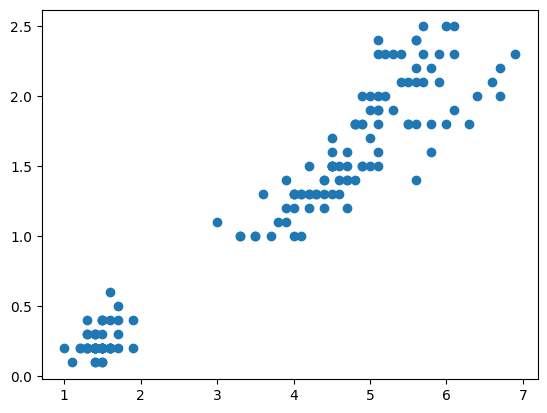

In [3]:
# Visualizando graficamente os pontos
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(X['petal length (cm)'], X['petal width (cm)'])

plt.show()

- **Utilizando o DBSCAN**
    - https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [4]:
# Importando o DBSCAN
from sklearn.cluster import DBSCAN

In [29]:
# Utilizando o algoritmo
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X)

In [30]:
# Verificando quais foram os labels determinados pelo dbscan
dbscan.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

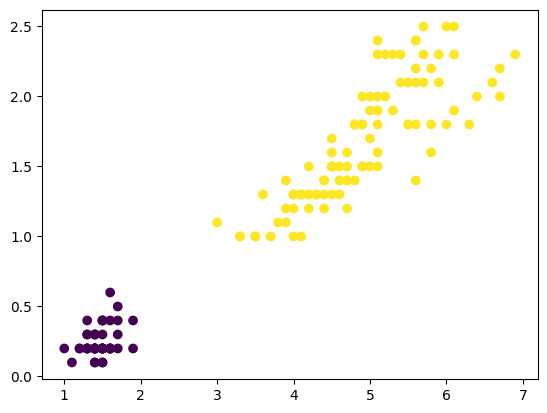

In [31]:
# Visualizando graficamente
fig, ax = plt.subplots()

ax.scatter(X['petal length (cm)'], X['petal width (cm)'], c=dbscan.labels_)

plt.show()

- **Avaliando os modelos**
    - https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation

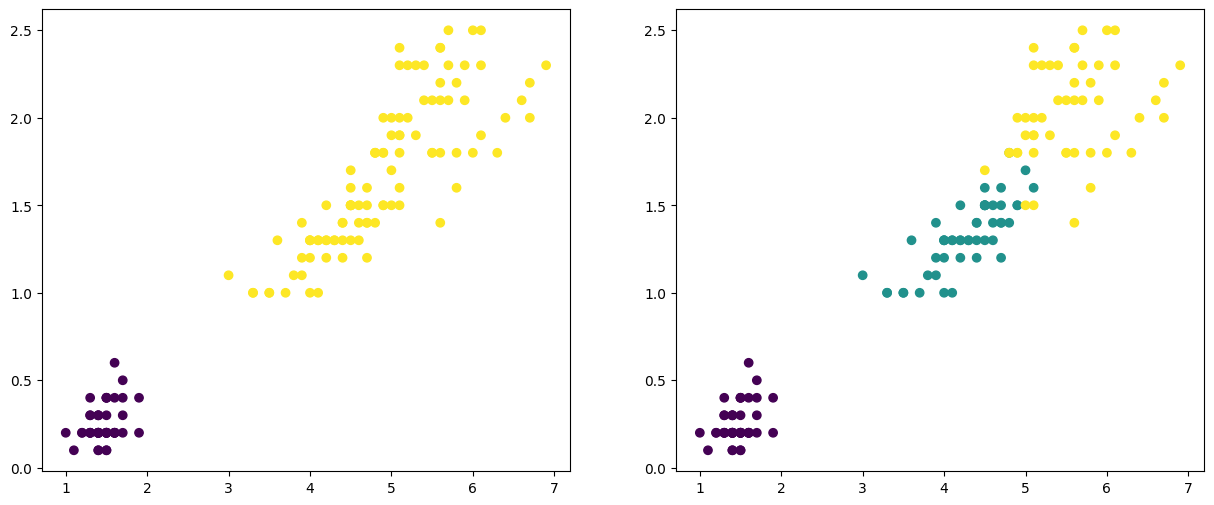

In [32]:
# Podemos visualizar o target e os labels em um mesmo gráfico
fig, ax = plt.subplots(ncols=2, figsize=(15, 6))

ax[0].scatter(X['petal length (cm)'], X['petal width (cm)'], c=dbscan.labels_)
ax[1].scatter(X['petal length (cm)'], X['petal width (cm)'], c=y)

plt.show()

- **Índice Rand**
    - https://scikit-learn.org/stable/modules/clustering.html#rand-index
    - mede a semelhança de classe entre 2 pontos
    - **Depende de termos os rótulos / labels**
    - A [fórmula é dada por](https://en.wikipedia.org/wiki/Rand_index):
        <img src="../../../images/kmeans/rand_index.png" style='width: 250px;' />
    - Onde:
        - a: número de pares que pertencem **a mesma classe e ao mesmo cluster**
        - b: número de pares que pertencem **a classes diferentes e a clusters diferentes**
        - c: número de pares que pertencem **a mesma classe e a clusters diferentes**
        - d: número de pares que pertencem **a classes diferentes e ao mesmo cluster**<br><br>
    - O Índice Rand tem alguns problemas como ter valores altos mesmo para dados aleatórios e aumentar a medida que aumentamos o número de grupos. Para resolver utilizamos o **Índice Rand Ajustado**, onde:
        - Para uma clusterização aleatória, seu valor é 0
        - O máximo é 1
        - Valores negativos representam clusterizações piores que escolher de forma aleatória os clusters

In [33]:
# Verificando o adjusted_rand_score
from sklearn import metrics

metrics.adjusted_rand_score(y, dbscan.labels_)

0.5681159420289855

- **"Coeficiente Silhueta"**
    - https://scikit-learn.org/stable/modules/clustering.html#silhouette-coefficient
    - Quanto maior esse coeficiente, mais bem definidos são os clusters do modelo
    - Vamos considerar 2 pontuações
        - **a:** A distância média **entre uma amostra e todos os outros pontos da mesma classe**
        - **b:** A distância média **entre uma amostra e todos os outros pontos no outro cluster mais próximo**
    - **Ele avalia tanto a distância intracluster (o quanto os pontos estão afastados dentro do próprio cluster) quando a distância interclusters (o quanto os clusters estão afastados entre si)**
    - O [coeficiente para uma amostra é dado pela fórmula abaixo](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html#sklearn.metrics.silhouette_samples)
    <img src="../../../images/kmeans/silhouette-coefficient.png" style='width: 250px;' />
    - O coeficiente para o conjunto de amostras é dado utilizando a média desse coeficiente para cada amostra

In [34]:
# Verificando o silhouette_score
metrics.silhouette_score(X, dbscan.labels_)

0.7669465622770762

- Há outras métricas melhores para avaliar o DBSCAN, a principal é a DBCV (Density-Based Clustering Validation)
    - Em vez de medir distâncias com uma régua, o DBCV avalia a qualidade da densidade:
        - Conectividade Interna: Verifica se os caminhos dentro do cluster mantêm uma densidade alta e consistente.
        - Separação Externa: Verifica se existe um "vale" (uma queda abrupta e real na densidade) entre um cluster e outro.

Assim como o Silhouette, o resultado do DBCV varia de -1 a +1 (onde valores mais altos indicam que o modelo separou perfeitamente as áreas densas das áreas vazias).